<a href="https://colab.research.google.com/github/adityarizqiqa/PCVK_Ganjil2026/blob/main/Week5_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

E-1 PERCOBAAN HISTOGRAM

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

<BarContainer object of 256 artists>

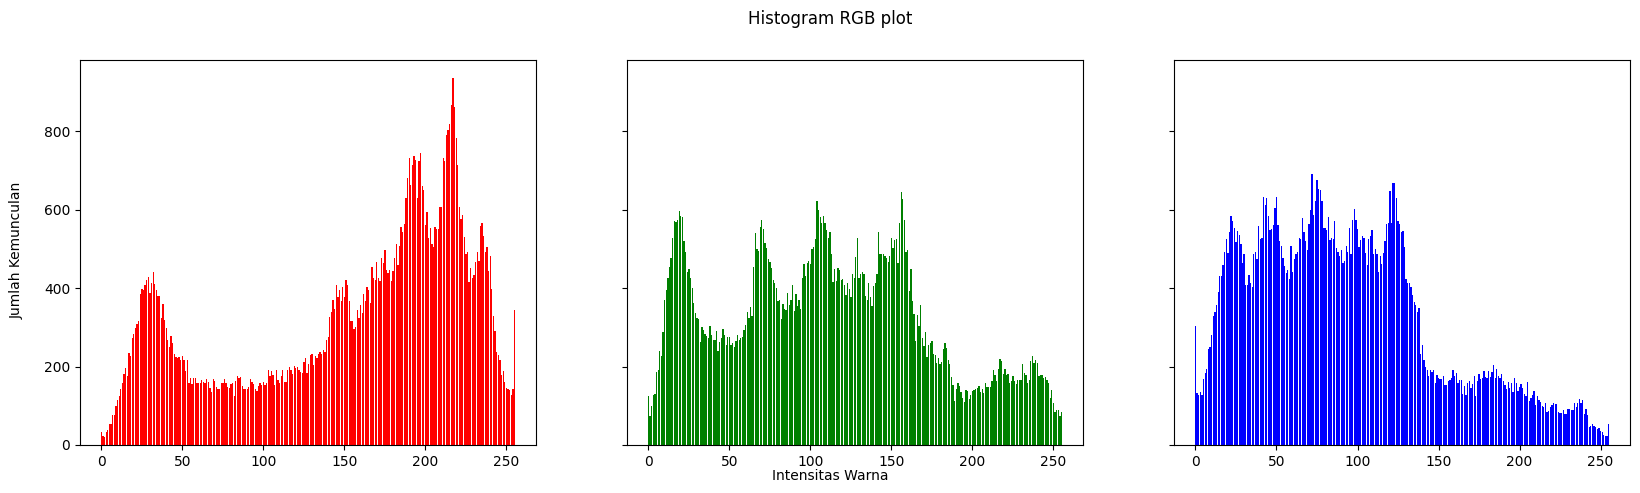

In [24]:
img = cv.imread('/content/drive/MyDrive/PCVK/lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
    for x in range(0,width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

PERTANYAAN PRAKTIKUM E1

In [25]:
import cv2 as cv
import numpy as np

def bandingkan_histogram(image_path):
    # Load citra
    img = cv.imread(image_path)
    if img is None:
        print(f"Gagal memuat citra: {image_path}. Silakan periksa kembali nama/path file Anda.")
        print("-" * 50)
        return

    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # 1. Perhitungan Manual (hanya mengambil channel Merah / Red sebagai contoh)
    height, width, depth = np.shape(img)
    hist_manual = [0] * 256
    for y in range(0, height):
        for x in range(0, width):
            hist_manual[img[y][x][0]] += 1

    # 2. Perhitungan menggunakan NumPy
    hist_np, bins = np.histogram(img[:,:,0], bins=256, range=(0, 256))

    # 3. Perhitungan menggunakan OpenCV
    hist_cv = cv.calcHist([img], [0], None, [256], [0, 256])

    # Menyamakan format menjadi array 1D integer
    hist_manual = np.array(hist_manual, dtype=np.int32)
    hist_np = np.array(hist_np, dtype=np.int32)
    hist_cv = np.array(hist_cv.flatten(), dtype=np.int32)

    # Menghitung selisih maksimum
    diff_manual_np = np.max(np.abs(hist_manual - hist_np))
    diff_manual_cv = np.max(np.abs(hist_manual - hist_cv))
    diff_np_cv = np.max(np.abs(hist_np - hist_cv))

    print(f"Hasil Perbandingan untuk citra: {image_path}")
    print(f"Selisih Maksimum Manual vs NumPy : {diff_manual_np}")
    print(f"Selisih Maksimum Manual vs OpenCV: {diff_manual_cv}")
    print(f"Selisih Maksimum NumPy vs OpenCV : {diff_np_cv}")
    print("-" * 50)

bandingkan_histogram('/content/drive/MyDrive/PCVK/lenna.png')
bandingkan_histogram('/content/drive/MyDrive/PCVK/KTM1b.jpeg')

Hasil Perbandingan untuk citra: /content/drive/MyDrive/PCVK/lenna.png
Selisih Maksimum Manual vs NumPy : 0
Selisih Maksimum Manual vs OpenCV: 0
Selisih Maksimum NumPy vs OpenCV : 0
--------------------------------------------------
Hasil Perbandingan untuk citra: /content/drive/MyDrive/PCVK/KTM1b.jpeg
Selisih Maksimum Manual vs NumPy : 0
Selisih Maksimum Manual vs OpenCV: 0
Selisih Maksimum NumPy vs OpenCV : 0
--------------------------------------------------


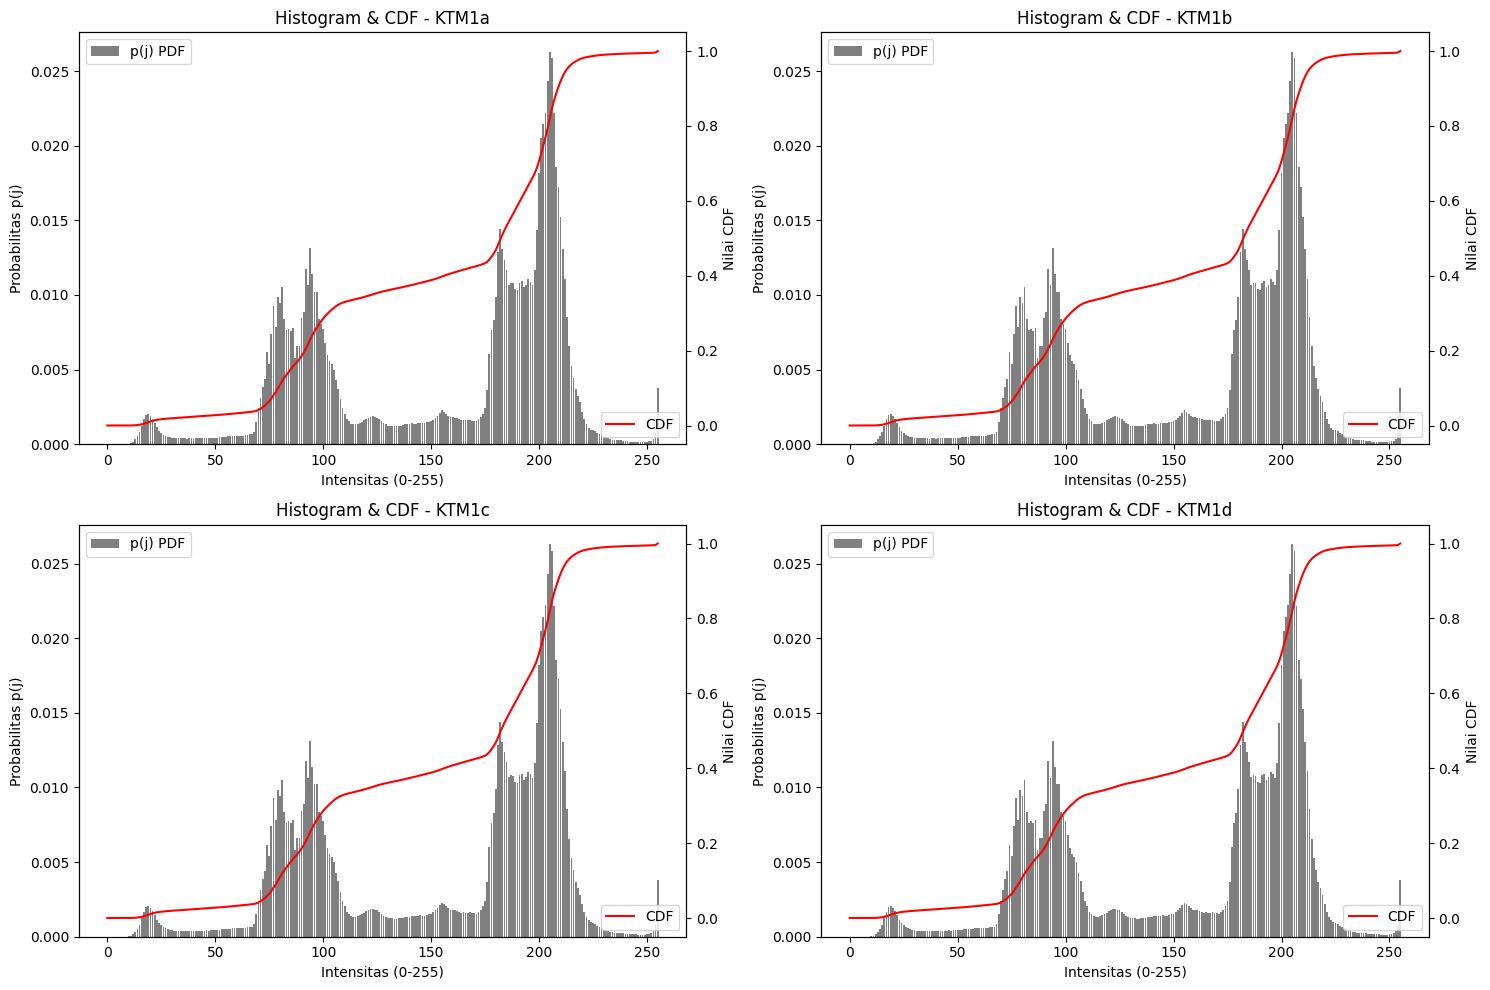

In [27]:
image_paths = [
    '/content/drive/MyDrive/PCVK/KTM1a.jpeg',
    '/content/drive/MyDrive/PCVK/KTM1b.jpeg',
    '/content/drive/MyDrive/PCVK/KTM1c.jpeg',
    '/content/drive/MyDrive/PCVK/KTM1d.jpeg'
]
titles = ['KTM1a', 'KTM1b', 'KTM1c', 'KTM1d']

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

for i, path in enumerate(image_paths):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if img is not None:
        hist = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()

        total_pixels = img.shape[0] * img.shape[1]
        pdf = hist / total_pixels
        cdf = np.cumsum(pdf)

        # Visualisasi
        axs[i].bar(np.arange(256), pdf, color='gray', label='p(j) PDF')
        ax2 = axs[i].twinx()
        ax2.plot(cdf, color='red', label='CDF')

        axs[i].set_title(f"Histogram & CDF - {titles[i]}")
        axs[i].set_xlabel("Intensitas (0-255)")
        axs[i].set_ylabel("Probabilitas p(j)")
        ax2.set_ylabel("Nilai CDF")
        axs[i].legend(loc='upper left')
        ax2.legend(loc='lower right')
    else:
        axs[i].set_title(f"Gagal memuat {titles[i]}")

plt.tight_layout()
plt.show()

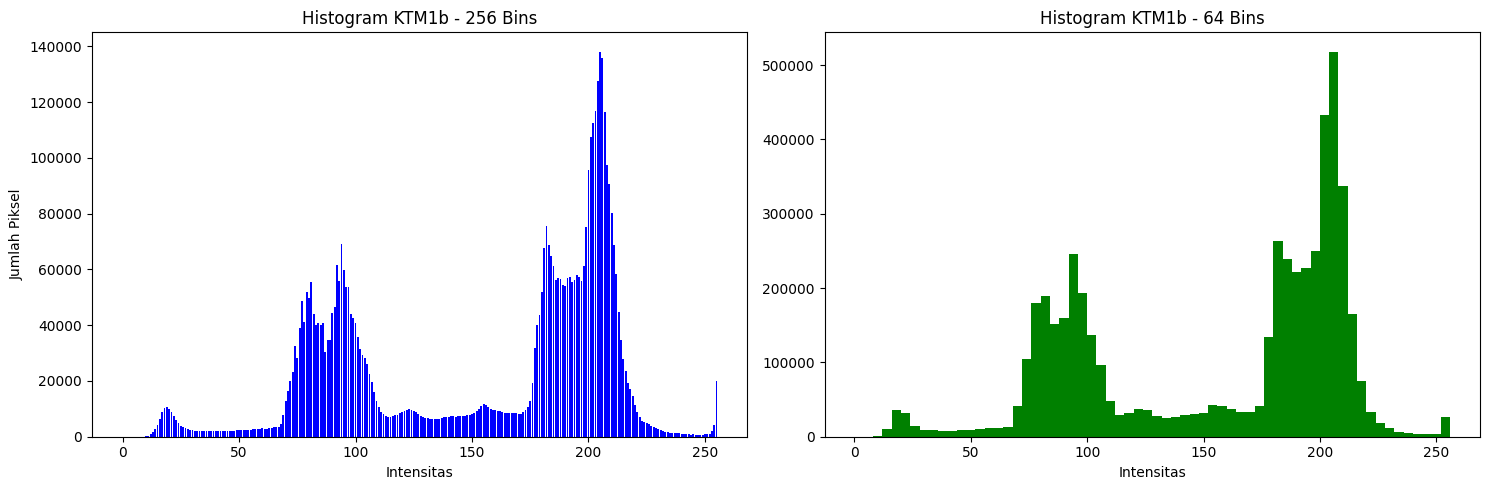

In [28]:
img = cv.imread('/content/drive/MyDrive/PCVK/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)

param_bins = 64
hist_256 = cv.calcHist([img], [0], None, [256], [0, 256])
hist_param = cv.calcHist([img], [0], None, [param_bins], [0, 256])

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot 256 bin
axs[0].bar(np.arange(256), hist_256.flatten(), color='blue')
axs[0].set_title('Histogram KTM1b - 256 Bins')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Piksel')

# Plot Param bins
# lebar bar menyesuaikan rasio kompresi bin (256/param_bins)
width_bar = 256 / param_bins
axs[1].bar(np.arange(0, 256, width_bar), hist_param.flatten(), width=width_bar, color='green', align='edge')
axs[1].set_title(f'Histogram KTM1b - {param_bins} Bins')
axs[1].set_xlabel('Intensitas')

plt.tight_layout()
plt.show()

E-2 PERCOBAAN HISTOGRAM EQUALIZATION

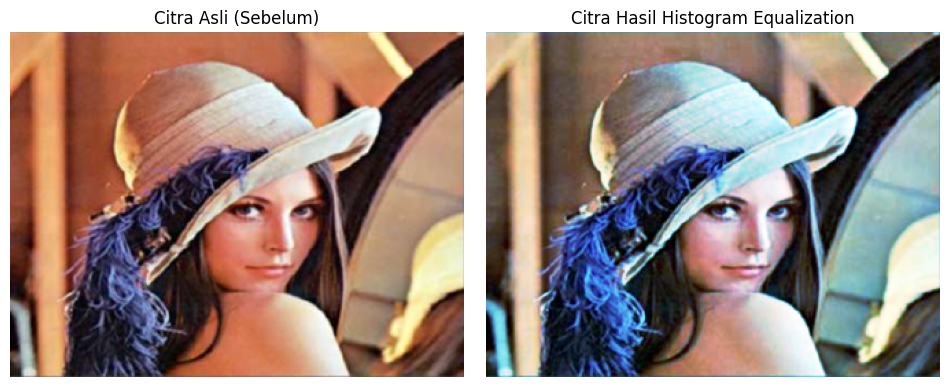

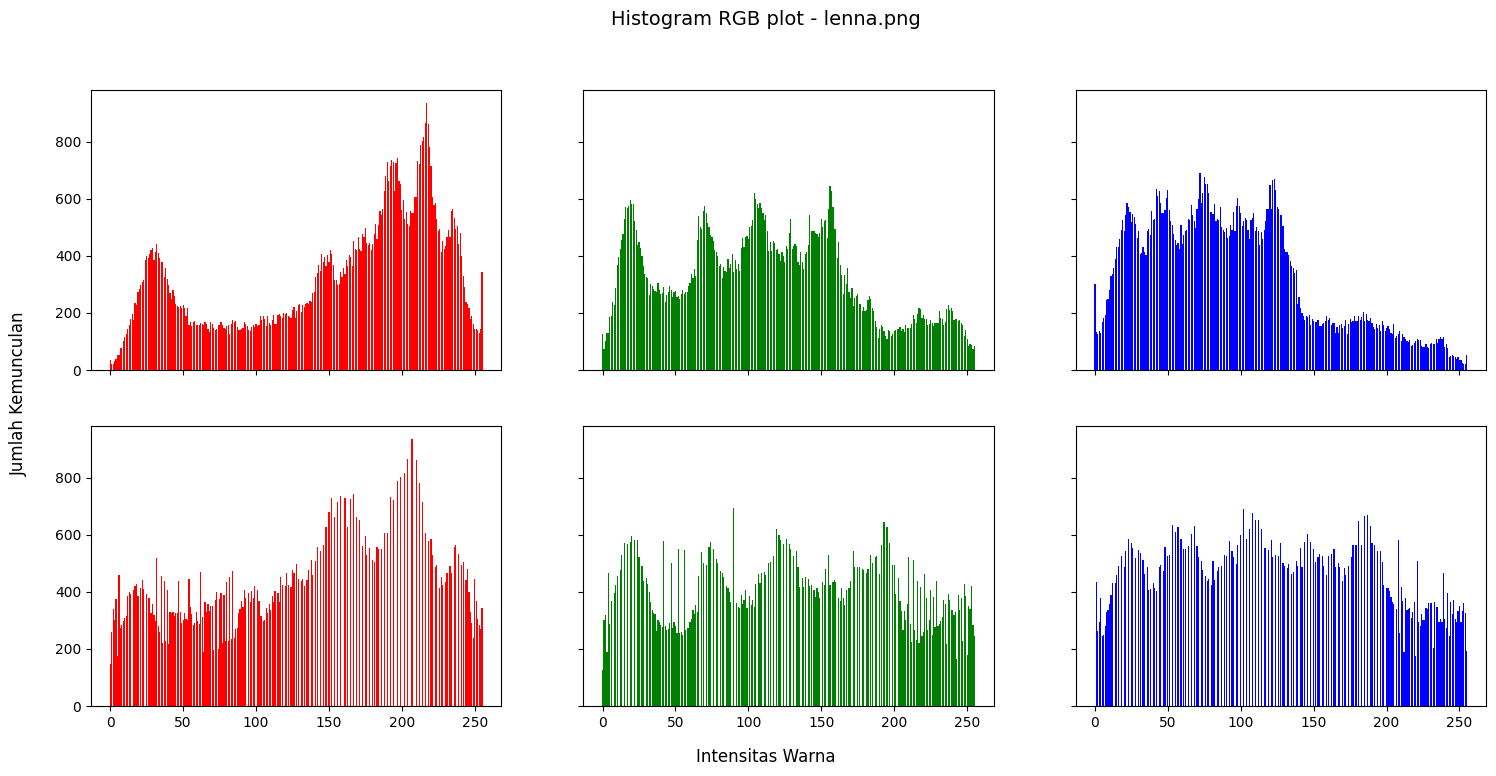

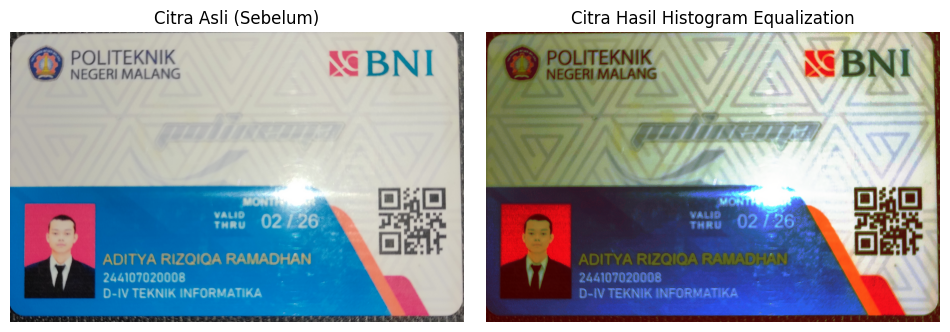

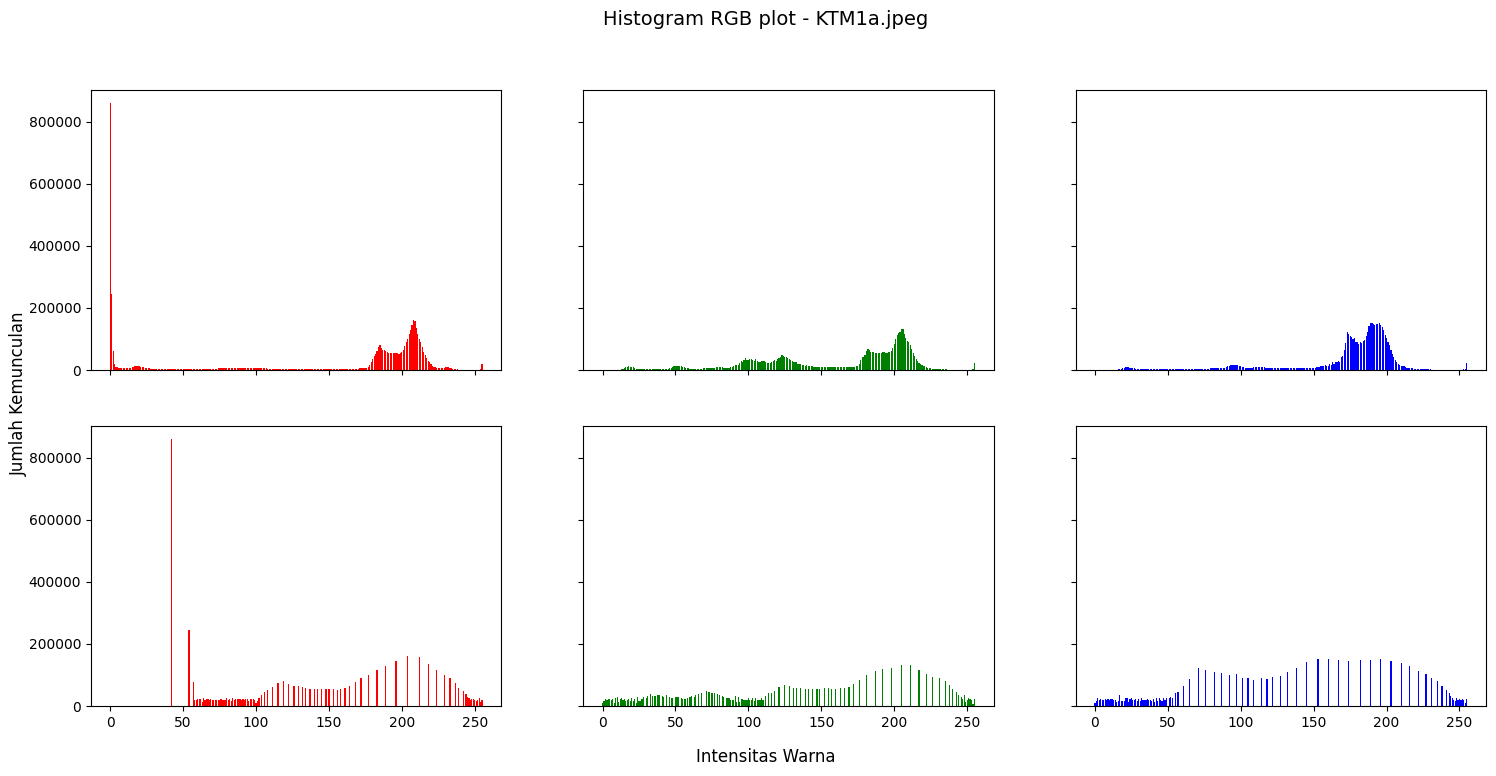

In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_equalization_rgb(image_path):
    # 1. Input image (sesuai flowchart)
    img = cv.imread(image_path)
    if img is None:
        print(f"Gagal memuat citra: {image_path}")
        return

    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    r, g, b = cv.split(img)

    # Fungsi internal untuk melakukan proses equalization pada satu channel saja
    def equalize_channel(channel):
        # Menghitung jumlah kemunculan (Frekuensi / Histogram)
        hist, _ = np.histogram(channel.flatten(), 256, [0, 256])

        # Penjumlahan kumulatif frekuensi (CDF)
        cdf = hist.cumsum()

        # Normalisasi (dibagi jumlah pixel lalu dikali skala warna / max pixel = 255)
        total_pixels = channel.shape[0] * channel.shape[1]
        cdf_normalized = cdf / total_pixels

        # Membuat array pemetaan (mapping) intensitas baru (0-255)
        mapping_array = np.round(cdf_normalized * 255).astype(np.uint8)

        # Transformasi kembali ke citra (memetakan pixel lama ke pixel baru)
        equalized_channel = mapping_array[channel]

        # Menghitung histogram baru untuk keperluan visualisasi/plot
        hist_eq, _ = np.histogram(equalized_channel.flatten(), 256, [0, 256])

        return equalized_channel, hist, hist_eq

    r_eq, r_hist, r_hist_eq = equalize_channel(r)
    g_eq, g_hist, g_hist_eq = equalize_channel(g)
    b_eq, b_hist, b_hist_eq = equalize_channel(b)

    img_eq = cv.merge((r_eq, g_eq, b_eq))

    # 1. Tampilan citra sebelum dan sesudah proses
    fig1, axs1 = plt.subplots(1, 2, figsize=(12, 6))
    axs1[0].imshow(img)
    axs1[0].set_title('Citra Asli (Sebelum)')
    axs1[0].axis('off')

    axs1[1].imshow(img_eq)
    axs1[1].set_title('Citra Hasil Histogram Equalization')
    axs1[1].axis('off')

    # Menghilangkan jarak (spasi)
    plt.subplots_adjust(wspace=0.05)
    plt.show()

    # 2. Tampilan plot Histogram RGB (2 baris x 3 kolom)
    fig2, axs2 = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
    fig2.suptitle(f'Histogram RGB plot - {image_path.split("/")[-1]}', fontsize=14)

    # Baris 1: Histogram Asli (Sebelum)
    axs2[0, 0].bar(np.arange(256), r_hist, color='red')
    axs2[0, 1].bar(np.arange(256), g_hist, color='green')
    axs2[0, 2].bar(np.arange(256), b_hist, color='blue')

    # Baris 2: Histogram Sesudah Equalization
    axs2[1, 0].bar(np.arange(256), r_hist_eq, color='red')
    axs2[1, 1].bar(np.arange(256), g_hist_eq, color='green')
    axs2[1, 2].bar(np.arange(256), b_hist_eq, color='blue')

    # Label Sumbu (Global)
    fig2.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical', fontsize=12)
    fig2.text(0.5, 0.04, 'Intensitas Warna', ha='center', fontsize=12)
    plt.show()

histogram_equalization_rgb('/content/drive/MyDrive/PCVK/lenna.png')
histogram_equalization_rgb('/content/drive/MyDrive/PCVK/KTM1a.jpeg')

In [30]:
import cv2 as cv
import numpy as np

def bandingkan_he_manual_cv(image_path):
    img = cv.imread(image_path)
    if img is None:
        print(f"Gagal memuat citra: {image_path}")
        return

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    r = img_rgb[:,:,0]

    # 1. Cara Manual
    hist, _ = np.histogram(r.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf / (r.shape[0] * r.shape[1])
    mapping_array = np.round(cdf_normalized * 255).astype(np.uint8)
    r_manual = mapping_array[r]

    # 2. Cara OpenCV
    r_cv = cv.equalizeHist(r)
    diff = np.max(np.abs(r_manual.astype(np.int16) - r_cv.astype(np.int16)))

    print(f"Selisih maksimum manual vs cv.equalizeHist pada {image_path.split('/')[-1]}: {diff}")

bandingkan_he_manual_cv('/content/drive/MyDrive/PCVK/lenna.png')
bandingkan_he_manual_cv('/content/drive/MyDrive/PCVK/KTM1a.jpeg')

Selisih maksimum manual vs cv.equalizeHist pada lenna.png: 1
Selisih maksimum manual vs cv.equalizeHist pada KTM1a.jpeg: 42


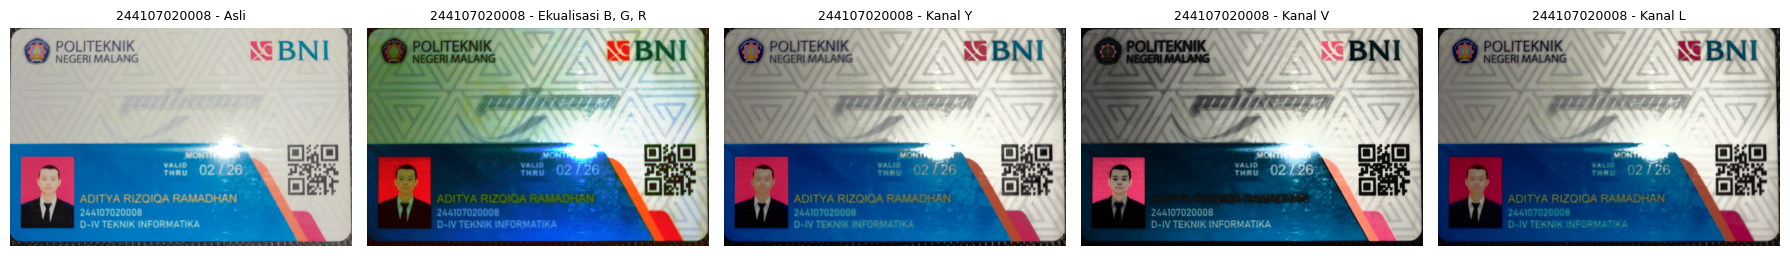


=== TABEL HASIL ANALISIS ===
Cara ekualisasi            geser Hue (der)    rerata terang
Asli                                  0.00            155.4
Ekualisasi B, G, R                   52.51            122.8
Kanal Y                               1.94            131.9
Kanal V                               3.12            112.7
Kanal L                               6.06            122.2
------------------------------------------------------------
Kanal L (CLAHE)                       3.99            152.0


In [31]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

berkas = '/content/drive/MyDrive/PCVK/KTM1d.jpeg'
bgr = cv.imread(berkas)

# Cara 1: Tiap kanal BGR diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# Cara 2: Hanya kanal terang yang diekualisasi di berbagai ruang warna
# YCrCb
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# HSV
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# LAB
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b_chan = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_chan]), cv.COLOR_LAB2BGR)


# Tampilkan kelimanya berdampingan
NIM = '244107020008'
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Fungsi menghitung pergeseran Hue
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d) # Hue melingkar 0-179
    return d.mean()

print("\n=== TABEL HASIL ANALISIS ===")
print('%-25s %16s %16s' % ('Cara ekualisasi', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-25s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))


# --- JAWABAN PERTANYAAN NOMOR 4 (CLAHE) ---
# Menggunakan CLAHE pada ruang warna LAB (Kanal L)
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_l = clahe.apply(l)
he_clahe = cv.cvtColor(cv.merge([clahe_l, a, b_chan]), cv.COLOR_LAB2BGR)

print('-' * 60)
print('%-25s %16.2f %16.1f' % ('Kanal L (CLAHE)', geser_hue(bgr, he_clahe) * 2, cv.cvtColor(he_clahe, cv.COLOR_BGR2GRAY).mean()))

PERTANYAAN PRAKTIKUM E2

/tmp/ipykernel_6129/390442328.py:36: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(img.flatten(), 256, [0, 256], color='gray')
/tmp/ipykernel_6129/390442328.py:38: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_manual.flatten(), 256, [0, 256], color='gray')
/tmp/ipykernel_6129/390442328.py:40: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 2].hist(img_cv.flatten(), 256, [0, 256], color='gray')


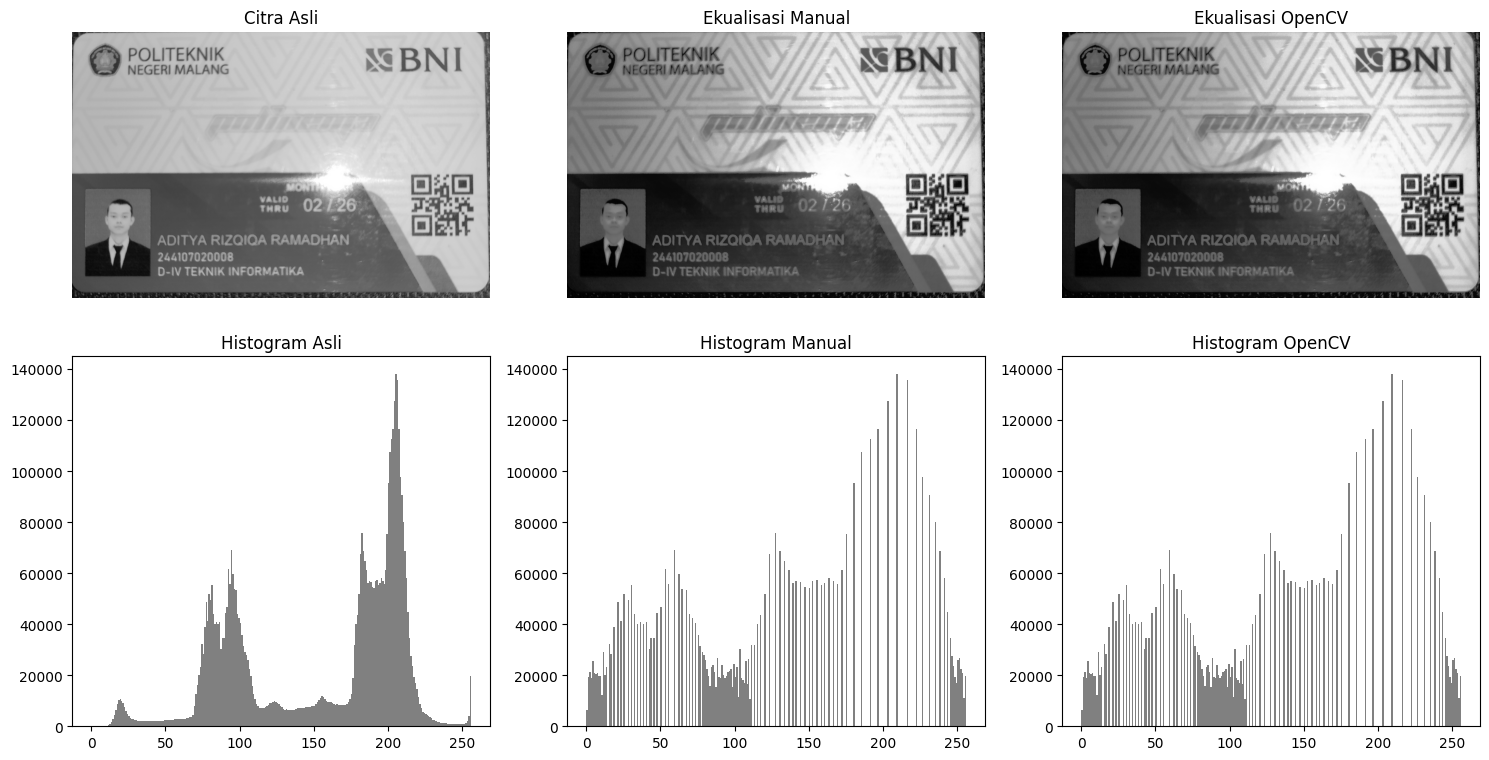

----------------------------------------
PSNR Citra Asli vs Ekualisasi Manual : 16.48 dB
PSNR Citra Asli vs Ekualisasi OpenCV : 16.48 dB


In [32]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# a. Load citra KTM1a versi Grayscale
path_ktm = '/content/drive/MyDrive/PCVK/KTM1a.jpeg'
img = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)

if img is None:
    print(f"Gagal memuat {path_ktm}")
else:
    # --- 1. Ekualisasi Manual ---
    hist_asli, _ = np.histogram(img.flatten(), 256, [0, 256])
    cdf = hist_asli.cumsum()
    cdf_normalized = cdf / (img.shape[0] * img.shape[1])
    mapping_array = np.round(cdf_normalized * 255).astype(np.uint8)
    img_manual = mapping_array[img]

    # --- 2. Ekualisasi cv.equalizeHist ---
    img_cv = cv.equalizeHist(img)

    # --- b. Menampilkan Citra Asli, Ekualisasi, dan Histogram ---
    fig, axs = plt.subplots(2, 3, figsize=(15, 8))

    # Baris 1: Citra
    axs[0, 0].imshow(img, cmap='gray')
    axs[0, 0].set_title('Citra Asli')
    axs[0, 1].imshow(img_manual, cmap='gray')
    axs[0, 1].set_title('Ekualisasi Manual')
    axs[0, 2].imshow(img_cv, cmap='gray')
    axs[0, 2].set_title('Ekualisasi OpenCV')

    for i in range(3): axs[0, i].axis('off')

    # Baris 2: Histogram
    axs[1, 0].hist(img.flatten(), 256, [0, 256], color='gray')
    axs[1, 0].set_title('Histogram Asli')
    axs[1, 1].hist(img_manual.flatten(), 256, [0, 256], color='gray')
    axs[1, 1].set_title('Histogram Manual')
    axs[1, 2].hist(img_cv.flatten(), 256, [0, 256], color='gray')
    axs[1, 2].set_title('Histogram OpenCV')

    plt.tight_layout()
    plt.show()

    # --- c. Hitung PSNR ---
    # PSNR mengukur rasio puncak sinyal terhadap noise (perbedaan antar citra)
    psnr_manual = cv.PSNR(img, img_manual)
    psnr_cv = cv.PSNR(img, img_cv)

    print("-" * 40)
    print(f"PSNR Citra Asli vs Ekualisasi Manual : {psnr_manual:.2f} dB")
    print(f"PSNR Citra Asli vs Ekualisasi OpenCV : {psnr_cv:.2f} dB")

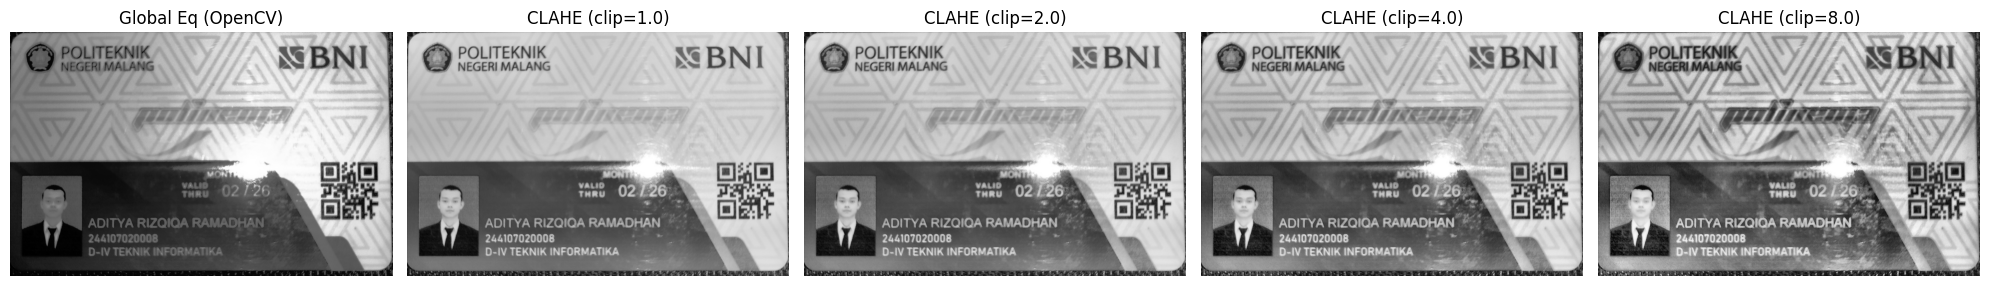

In [33]:
if img is not None:
    param_clip = 2.0
    param_tile = 8

    # --- a. Penerapan CLAHE default ---
    clahe_default = cv.createCLAHE(clipLimit=param_clip, tileGridSize=(param_tile, param_tile))
    img_clahe_default = clahe_default.apply(img)

    # --- b. Percobaan 3 nilai clipLimit lain ---
    clips = [1.0, param_clip, 4.0, 8.0]
    hasil_clahe = []

    for c in clips:
        clahe = cv.createCLAHE(clipLimit=c, tileGridSize=(param_tile, param_tile))
        hasil_clahe.append(clahe.apply(img))

    # --- Menampilkan Perbandingan Global Eq vs CLAHE ---
    fig, axs = plt.subplots(1, 5, figsize=(20, 5))

    # Menampilkan ekualisasi global dari jawaban Soal 1 (img_cv)
    axs[0].imshow(img_cv, cmap='gray')
    axs[0].set_title('Global Eq (OpenCV)')
    axs[0].axis('off')

    for i in range(4):
        axs[i+1].imshow(hasil_clahe[i], cmap='gray')
        axs[i+1].set_title(f'CLAHE (clip={clips[i]})')
        axs[i+1].axis('off')

    plt.tight_layout()
    plt.show()

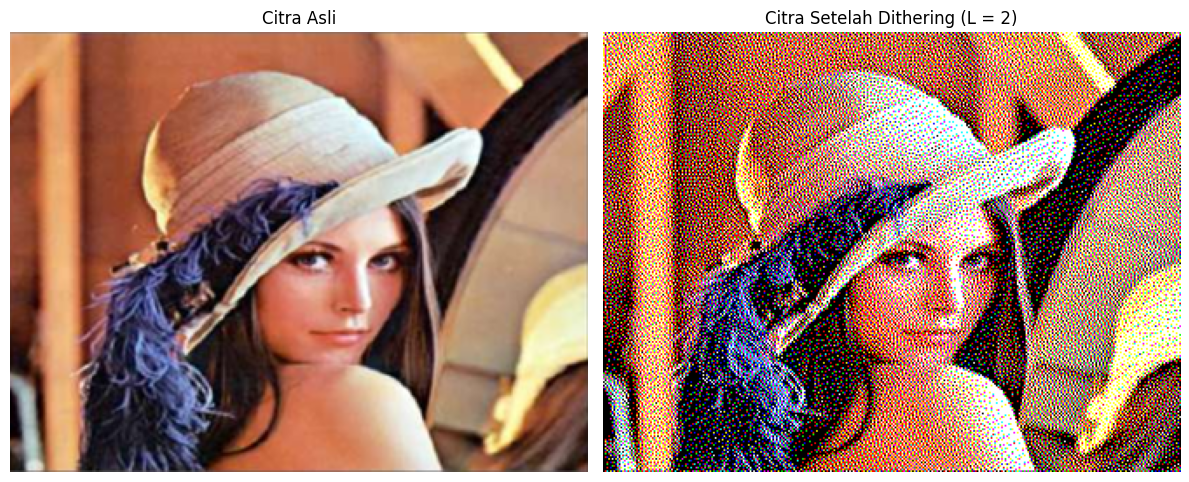

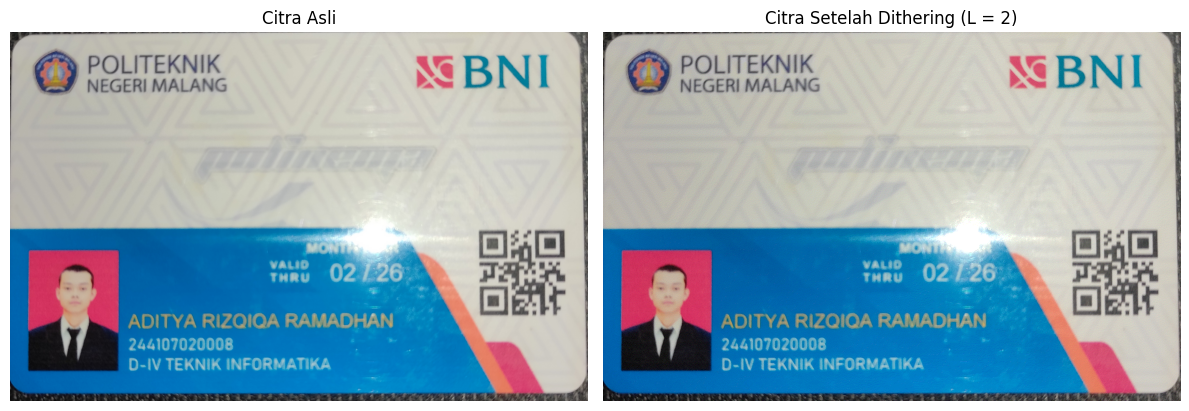

In [35]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg(channel, L):
    img = channel.astype(np.float32)
    step = 255.0 / (L - 1)
    H, W = img.shape

    # Looping baris (y) dan kolom (x)
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            # Distribusi error ke piksel tetangga
            if x + 1 < W:
                img[y, x + 1] += error * (7 / 16)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3 / 16)
            if y + 1 < H:
                img[y + 1, x] += error * (5 / 16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1 / 16)

    # Membatasi nilai ke 0-255 lalu ubah ke uint8
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def apply_dithering_color(image_path, L):
    img = cv.imread(image_path)
    if img is None:
        print(f"Gagal memuat citra: {image_path}")
        return
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Pisahkan kanal sesuai catatan modul
    r, g, b = cv.split(img)

    # Penerapan dithering pada masing-masing kanal
    r_dither = floyd_steinberg(r, L)
    g_dither = floyd_steinberg(g, L)
    b_dither = floyd_steinberg(b, L)

    img_dither = cv.merge((r_dither, g_dither, b_dither))

    # Tampilkan Hasil
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(img)
    axs[0].set_title('Citra Asli')
    axs[0].axis('off')

    axs[1].imshow(img_dither)
    axs[1].set_title(f'Citra Setelah Dithering (L = {L})')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

apply_dithering_color('/content/drive/MyDrive/PCVK/lenna.png', L=2)
param_L = 2
apply_dithering_color('/content/drive/MyDrive/PCVK/KTM1b.jpeg', L=param_L)

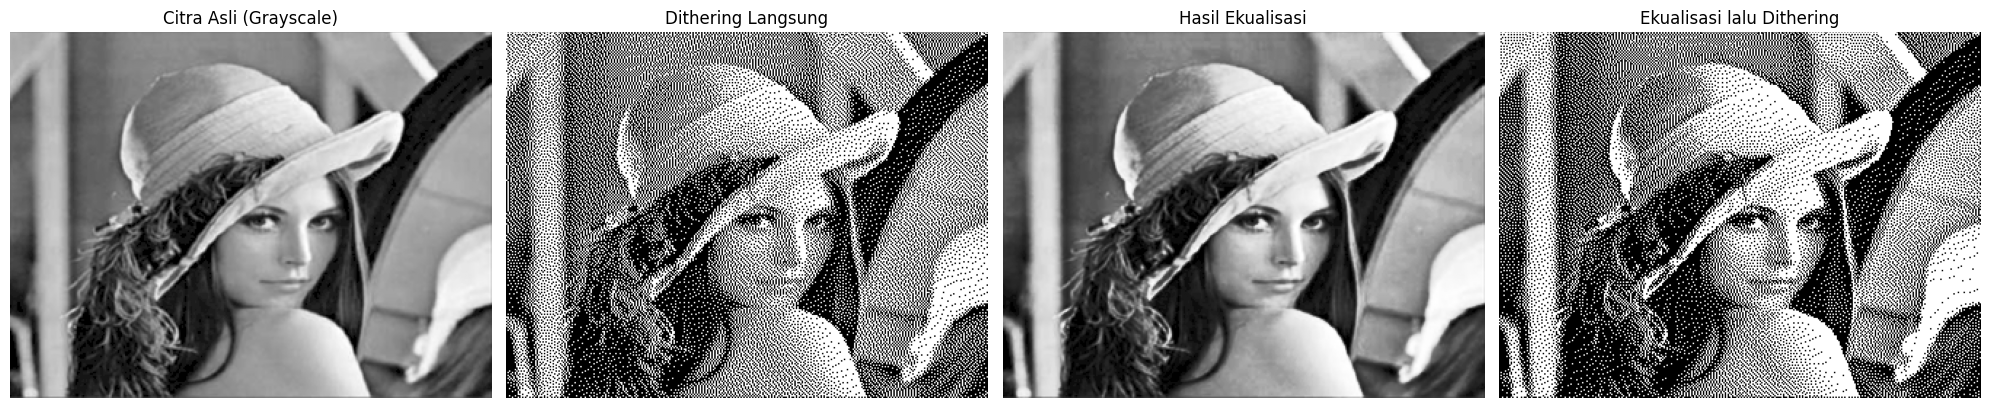

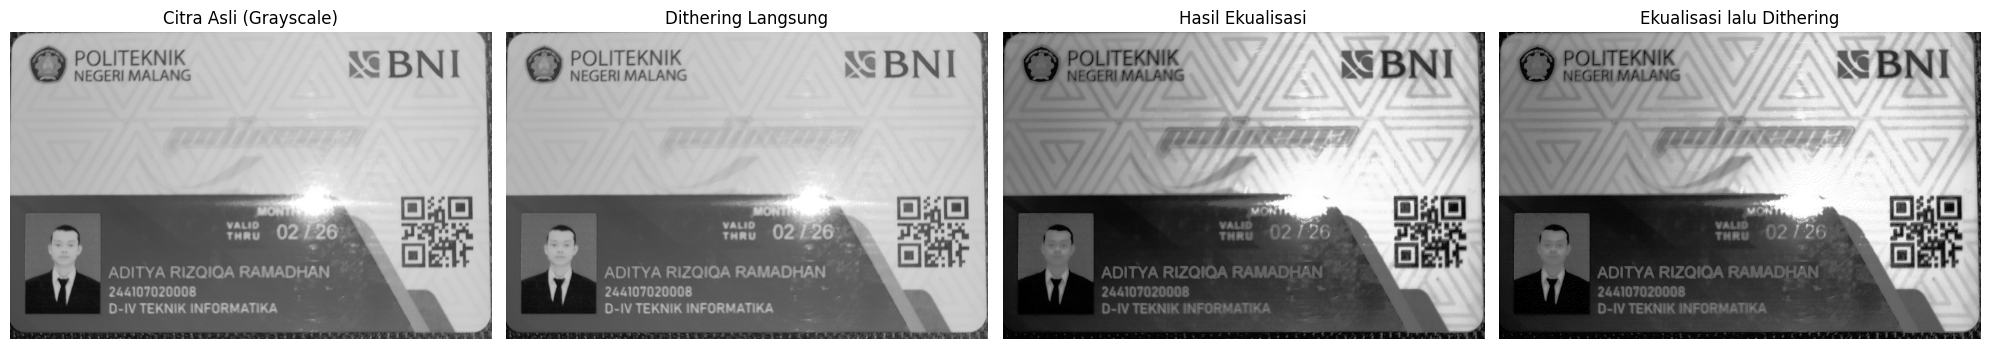

In [39]:
def bandingkan_dithering_grayscale(image_path):
    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Gagal memuat citra: {image_path}")
        return

    L = 2 # Menggunakan 2 level untuk efek hitam-putih biner

    # 1. Dithering Langsung
    img_dither_langsung = floyd_steinberg(img.copy(), L)

    # 2. Histogram Equalization terlebih dahulu
    img_eq = cv.equalizeHist(img)

    # 3. Ekualisasi lalu Dithering
    img_eq_dither = floyd_steinberg(img_eq.copy(), L)

    # Tampilkan 4 citra berdampingan sesuai contoh di modul
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    axs[0].imshow(img, cmap='gray')
    axs[0].set_title('Citra Asli (Grayscale)')

    axs[1].imshow(img_dither_langsung, cmap='gray')
    axs[1].set_title('Dithering Langsung')

    axs[2].imshow(img_eq, cmap='gray')
    axs[2].set_title('Hasil Ekualisasi')

    axs[3].imshow(img_eq_dither, cmap='gray')
    axs[3].set_title('Ekualisasi lalu Dithering')

    for ax in axs: ax.axis('off')
    plt.tight_layout()
    plt.show()

bandingkan_dithering_grayscale('/content/drive/MyDrive/PCVK/lenna_lc.png')
bandingkan_dithering_grayscale('/content/drive/MyDrive/PCVK/KTM1a.jpeg')